In [1]:
2+2


4

In [2]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI
import operator
from langchain_core.messages import HumanMessage,SystemMessage
from dotenv import load_dotenv
load_dotenv()
generate_llm=ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.5
)
evaluate_llm=ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.5
)
optimise_llm=ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.5
)

## State Define

In [3]:
class State(TypedDict):
    tweet:str
    topic:str
    evaluation:Literal["approved","need_improvement"]
    feedback:str
    iteration:int
    max_iteration:int
    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]
    

    

In [4]:
class EvaluateSchema(BaseModel):
    evaluation:Literal["approved","need_imporovement"]=Field(...,description="final evaluation result...")
    feedback: str=Field(...,description="feedback for the tweeet...")

str_evaluator_llm=evaluate_llm.with_structured_output(EvaluateSchema)    

In [5]:
graph=StateGraph(State)

In [6]:
def generate_tweet(state:State):
    message=[
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """
        )
    ]
    response=generate_llm.invoke(message)
    return {
        "tweet":response.content,
        "tweet_history":[response.content]
    }

def evaluate_tweet(state:State):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality- Is this fresh, or have you seen it a hundred times before?  
        2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness - Is it short, sharp, and scroll-stopping?  
        4. Virality Potential - Would people retweet or share it?  
        5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """
        )
    ]
    response=str_evaluator_llm.invoke(messages)

    return {
        "evaluation":response.evaluation,
        "feedback":response.feedback,
        "feedback_history":[response.feedback]
    }
def optimise_tweet(state:State):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    response=optimise_llm.invoke(messages)
    iteration=state[iteration]+1
    return {
        "tweet":response.content,
        "tweet_history":[response.content],
        "iteration":iteration
    }

def conditional_func(state:State)->Literal["need_improvement","approved"]:
    if state['evaluation']=="approved" or state['iteration']>=state['max_iteration']:
        return "approved"
    else:
        return "need_improvement"


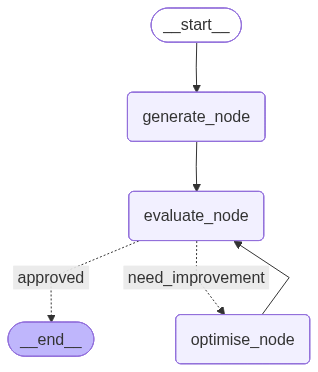

In [7]:

graph.add_node("generate_node",generate_tweet)
graph.add_node("evaluate_node",evaluate_tweet)
graph.add_node("optimise_node",optimise_tweet)

graph.add_edge(START,"generate_node")
graph.add_edge("generate_node","evaluate_node")
graph.add_conditional_edges("evaluate_node",conditional_func,{
    "need_improvement":"optimise_node",
    "approved":END
})
graph.add_edge("optimise_node","evaluate_node")

workflow=graph.compile()
workflow


In [15]:
initial_state={
    "topic":"AI",
    "max_iteration":5,
    "iteration":1
}

workflow.invoke(initial_state)



{'tweet': "AI is like a toddler with a PhD—super smart but still insists on coloring outside the lines. One minute it's writing Shakespeare, the next it's convinced a toaster is plotting world domination. Just waiting for it to throw a tantrum over low battery! 🔋🤖 #AIAdventures",
 'topic': 'AI',
 'evaluation': 'approved',
 'feedback': "This tweet is quite original, presenting a fresh metaphor that compares AI to a toddler with a PhD, which is a clever and relatable concept. The humor is strong, as it evokes a chuckle with the absurdity of AI's unpredictability and the imagery of a toddler throwing a tantrum over low battery. The punchiness is effective, as it delivers a concise message that captures attention without dragging on. Its virality potential is high, given the relatable nature of technology mishaps and the humorous tone, which encourages sharing. The format is well-structured, adhering to the character limit and avoiding traditional joke setups.",
 'iteration': 1,
 'max_iter